# 03 · Padrões Pré-Troca — Validação de Thresholds

**Objetivo:** para cada ciclo genuíno (target_rul < 20h na troca), medir com quanto
de antecedência cada sinal dos dois eixos cruzou seu threshold.

Isso responde:
- O `score_roll7d ≥ 0.60` detecta a degradação com antecedência suficiente?
- O `slope_Media_7d < -50 N/dia` e os outros sinais do Eixo 2 são confiáveis?
- Combinando Eixo 1 + Eixo 2, qual a cobertura total e o lead time médio?

| Etapa | Descrição |
|---|---|
| A | Carregar saídas dos notebooks 01 e 02 |
| B | Tabela de antecedência: por ciclo genuíno × sinal |
| C | Análise de cobertura e lead time por sinal |
| D | Combinação Eixo 1 OR Eixo 2 — cobertura total |
| E | Visualização — heatmap de antecedência |
| F | Exportar `03_padroes.csv` |

In [9]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Thresholds (mesmos do trigger_engine.py) ─────────────────────────────────
LIMIAR_GENUINO_H       = 20     # target_rul < N horas → ciclo genuíno
SCORE_CRITICO          = 0.60   # Eixo 1
SLOPE_THRESHOLD        = -50.0  # N/dia
FORCA_LIMIAR           = 800.0  # N
PCT_LIMIAR             = 0.05   # 5% de leituras abaixo de 800N
SUSTENTACAO_MINIMA_D   = 14     # dias sustentados ≥ score_critico para disparar G1

ARQUIVO_TROCAS    = '../troca_modulo.csv'
COLUNA_DATA_TROCA = 'Data-base do inicio'
# ─────────────────────────────────────────────────────────────────────────────
print('Configurações OK')

Configurações OK


## Etapa A — Carregar saídas de 01 e 02

In [10]:
v1 = pd.read_csv('01_vida_rul.csv',    parse_dates=['Timestamp'])
v2 = pd.read_csv('02_sinais_forca.csv', parse_dates=['Timestamp'])

v1['Timestamp'] = pd.to_datetime(v1['Timestamp'], utc=True)
v2['Timestamp'] = pd.to_datetime(v2['Timestamp'], utc=True)

# Merge pelos dois índices temporais
df = v1.merge(v2[['Timestamp', 'Media', 'Delta_AB',
                   'slope_Media_7d', 'pct_abaixo_800N_7d',
                   'min_forca_3d', 'cv_Delta_AB_7d']],
              on='Timestamp', how='left')

# Carregar trocas para filtrar ciclos genuínos
tc = pd.read_csv(ARQUIVO_TROCAS, parse_dates=[COLUNA_DATA_TROCA])
tc = tc.sort_values(COLUNA_DATA_TROCA).reset_index(drop=True)
troca_dates = pd.to_datetime(tc[COLUNA_DATA_TROCA]).dt.tz_localize('UTC').tolist()

# Recomputar target_rul a partir das trocas (mais confiável)
df['target_rul_h'] = np.nan
for i, t_fim in enumerate(troca_dates[1:], start=1):
    t_ini = troca_dates[i - 1]
    mask  = (df['Timestamp'] >= t_ini) & (df['Timestamp'] < t_fim)
    df.loc[mask, 'target_rul_h'] = (
        (t_fim - df.loc[mask, 'Timestamp']).dt.total_seconds() / 3600
    ).values

print(f'Linhas merged  : {len(df)}')
print(f'Ciclos únicos  : {df["ciclo_id"].nunique()}')
print(f'Colunas        : {list(df.columns)}')

Linhas merged  : 3019
Ciclos únicos  : 27
Colunas        : ['Timestamp', 'horas_desde_troca', 'ciclo_id', 'score_weibull', 'score_roll7d', 'rul_p10', 'rul_p50', 'rul_p90', 'Media', 'Delta_AB', 'slope_Media_7d', 'pct_abaixo_800N_7d', 'min_forca_3d', 'cv_Delta_AB_7d', 'target_rul_h']


## Etapa B — Tabela de antecedência por ciclo genuíno × sinal

Para cada ciclo genuíno: quando (dias antes da troca) cada sinal cruzou seu threshold
pela primeira vez?

In [11]:
def primeiro_cruzamento_dias(ciclo_df, t_troca, col, cond_fn):
    """Retorna dias de antecedência do primeiro cruzamento, ou None."""
    sub = ciclo_df[ciclo_df[col].notna()]
    sub = sub[cond_fn(sub[col])]
    if sub.empty:
        return None
    primeiro = sub.iloc[0]['Timestamp']
    return (t_troca - primeiro).total_seconds() / 86400


def dias_sustentados(ciclo_df, t_troca, col, cond_fn, min_dias=SUSTENTACAO_MINIMA_D):
    """Dias antes da troca em que col ficou sustentado >= min_dias consecutivos acima."""
    sub = ciclo_df[ciclo_df[col].notna()].copy()
    if sub.empty:
        return None
    sub['above'] = cond_fn(sub[col]).astype(int)
    # Janela deslizante: verifica se os próximos 14 dias (contínuos) ficam acima
    sub = sub.set_index('Timestamp')
    rolling_mean = sub['above'].rolling(f'{min_dias}D', min_periods=1).mean()
    # Ponto em que a média rolante de 14d chegou a 1.0 pela primeira vez
    candidates = rolling_mean[rolling_mean >= 1.0]
    if candidates.empty:
        return None
    primeiro = candidates.index[0]
    return (t_troca - primeiro).total_seconds() / 86400


registros = []

for i, (t_ini, t_fim) in enumerate(zip(troca_dates[:-1], troca_dates[1:])):
    ciclo_df = df[(df['Timestamp'] >= t_ini) & (df['Timestamp'] < t_fim)].copy()
    if ciclo_df.empty:
        continue

    rul_fim = ciclo_df['target_rul_h'].iloc[-1] if ciclo_df['target_rul_h'].notna().any() else np.nan
    genuino = pd.notna(rul_fim) and rul_fim < LIMIAR_GENUINO_H

    dur_h   = ciclo_df['horas_desde_troca'].max()

    rec = {
        'ciclo_id'      : i,
        'troca_ini'     : t_ini.date(),
        'troca_fim'     : t_fim.date(),
        'dur_dias'      : round(dur_h / 24, 1) if pd.notna(dur_h) else None,
        'rul_fim_h'     : round(rul_fim, 1) if pd.notna(rul_fim) else None,
        'genuino'       : genuino,
    }

    if genuino:
        # Eixo 1 — score_roll7d cruzou 0.60
        rec['e1_cruzou']       = primeiro_cruzamento_dias(
            ciclo_df, t_fim, 'score_roll7d', lambda s: s >= SCORE_CRITICO)
        # Eixo 1 — score sustentado 14d
        rec['e1_sustentado']   = dias_sustentados(
            ciclo_df, t_fim, 'score_roll7d', lambda s: s >= SCORE_CRITICO)
        # Eixo 2 — slope < -50
        rec['e2_slope']        = primeiro_cruzamento_dias(
            ciclo_df, t_fim, 'slope_Media_7d', lambda s: s < SLOPE_THRESHOLD)
        # Eixo 2 — pct_abaixo > 5%
        rec['e2_pct']          = primeiro_cruzamento_dias(
            ciclo_df, t_fim, 'pct_abaixo_800N_7d', lambda s: s > PCT_LIMIAR)
        # Eixo 2 — min_forca < 800N
        rec['e2_min']          = primeiro_cruzamento_dias(
            ciclo_df, t_fim, 'min_forca_3d', lambda s: s < FORCA_LIMIAR)

    registros.append(rec)

padroes = pd.DataFrame(registros)
genuinos = padroes[padroes['genuino']].copy()

print(f'Ciclos totais   : {len(padroes)}')
print(f'Ciclos genuínos : {len(genuinos)}')
print()
display(genuinos[['ciclo_id', 'troca_fim', 'dur_dias', 'rul_fim_h',
                   'e1_cruzou', 'e1_sustentado', 'e2_slope', 'e2_pct', 'e2_min']].round(1))

Ciclos totais   : 29
Ciclos genuínos : 25



,ciclo_id,troca_fim,dur_dias,rul_fim_h,e1_cruzou,e1_sustentado,e2_slope,e2_pct,e2_min
0,1,2022-08-19,56.6,9.7,2.4,NaN,51.4,42.4,42.4
2,3,2022-11-30,47.9,1.9,NaN,NaN,46.1,39.1,39.1
3,4,2022-12-16,15.6,9.9,NaN,NaN,6.0,15.7,15.7
5,6,2023-05-12,146.9,1.5,77.0,77.0,76.1,77.0,77.0
6,7,2023-06-26,191.6,9.8,44.7,44.7,30.1,44.4,44.4
7,8,2023-06-27,192.9,1.8,0.7,0.7,NaN,NaN,NaN
9,10,2024-01-22,26.7,8.3,NaN,NaN,22.0,25.3,25.3
10,11,2024-03-16,53.4,14.4,NaN,NaN,9.4,54.0,54.0
11,12,2024-05-07,51.7,7.8,NaN,NaN,40.7,42.0,42.3
12,13,2024-06-14,37.7,7.9,NaN,NaN,30.3,21.0,21.3


## Etapa C — Cobertura e lead time por sinal

In [12]:
sinais = {
    'e1_cruzou'    : 'Eixo1: score_roll7d ≥ 0.60',
    'e1_sustentado': f'Eixo1: sustentado {SUSTENTACAO_MINIMA_D}d',
    'e2_slope'     : 'Eixo2: slope < -50 N/dia',
    'e2_pct'       : 'Eixo2: pct_abaixo > 5%',
    'e2_min'       : 'Eixo2: min_forca < 800N',
}

n_gen = len(genuinos)
print(f'Ciclos genuínos analisados: {n_gen}')
print()
print(f'{"Sinal":<38}  {"Cobertura":>10}  {"Median d":>9}  {"P10 d":>7}  {"P90 d":>7}  {"Min d":>7}')
print('-' * 85)

resumo_sinais = []
for col, label in sinais.items():
    vals = genuinos[col].dropna()
    cobertura = len(vals) / n_gen
    if len(vals) > 0:
        med  = vals.median()
        p10  = vals.quantile(0.10)
        p90  = vals.quantile(0.90)
        vmin = vals.min()
    else:
        med = p10 = p90 = vmin = None
    print(f'{label:<38}  {cobertura:>9.0%}  '
          f'{med:>9.1f}  {p10:>7.1f}  {p90:>7.1f}  {vmin:>7.1f}' if med else
          f'{label:<38}  {cobertura:>9.0%}  {"—":>9}  {"—":>7}  {"—":>7}  {"—":>7}')
    resumo_sinais.append({'sinal': col, 'label': label, 'cobertura': cobertura,
                          'mediana_d': med, 'p10_d': p10, 'p90_d': p90, 'min_d': vmin})

resumo_sinais_df = pd.DataFrame(resumo_sinais)

Ciclos genuínos analisados: 25

Sinal                                    Cobertura   Median d    P10 d    P90 d    Min d
-------------------------------------------------------------------------------------
Eixo1: score_roll7d ≥ 0.60                    28%       44.7      1.7     98.4      0.7
Eixo1: sustentado 14d                         20%       44.7     14.3    100.6      0.7
Eixo2: slope < -50 N/dia                      88%       28.9      7.2     74.7      3.4
Eixo2: pct_abaixo > 5%                        84%       34.0     15.7     77.0      6.0
Eixo2: min_forca < 800N                       88%       30.1      9.4     75.2      4.0


## Etapa D — Combinação Eixo 1 OR Eixo 2

Um ciclo é coberto se **pelo menos um** sinal cruzou seu threshold antes da troca.

In [13]:
# Para cada ciclo: qual foi o sinal mais antecipado?
sinal_cols = list(sinais.keys())
genuinos['lead_e1'] = genuinos[['e1_cruzou', 'e1_sustentado']].max(axis=1)
genuinos['lead_e2'] = genuinos[['e2_slope', 'e2_pct', 'e2_min']].max(axis=1)
genuinos['lead_combinado'] = genuinos[sinal_cols].max(axis=1)  # melhor antecipação

coberto_e1   = genuinos['lead_e1'].notna().sum()
coberto_e2   = genuinos['lead_e2'].notna().sum()
coberto_comb = genuinos['lead_combinado'].notna().sum()

print('=' * 55)
print('  COBERTURA COMBINADA (Eixo 1 OR Eixo 2)')
print('=' * 55)
print(f'  Apenas Eixo 1       : {coberto_e1:2d} / {n_gen}  ({coberto_e1/n_gen:.0%})')
print(f'  Apenas Eixo 2       : {coberto_e2:2d} / {n_gen}  ({coberto_e2/n_gen:.0%})')
print(f'  Combinado (E1 OR E2): {coberto_comb:2d} / {n_gen}  ({coberto_comb/n_gen:.0%})')
print()

lc = genuinos['lead_combinado'].dropna()
if len(lc) > 0:
    print(f'  Lead time combinado — mediana: {lc.median():.1f}d  '
          f'P10: {lc.quantile(0.1):.1f}d  P90: {lc.quantile(0.9):.1f}d')
print('=' * 55)

print()
print('Ciclos SEM detecção por nenhum sinal:')
nao_cobertos = genuinos[genuinos['lead_combinado'].isna()]
if nao_cobertos.empty:
    print('  Nenhum — cobertura total!')
else:
    display(nao_cobertos[['ciclo_id', 'troca_fim', 'dur_dias', 'rul_fim_h']])

  COBERTURA COMBINADA (Eixo 1 OR Eixo 2)
  Apenas Eixo 1       :  7 / 25  (28%)
  Apenas Eixo 2       : 23 / 25  (92%)
  Combinado (E1 OR E2): 24 / 25  (96%)

  Lead time combinado — mediana: 29.0d  P10: 7.5d  P90: 72.7d

Ciclos SEM detecção por nenhum sinal:


,ciclo_id,troca_fim,dur_dias,rul_fim_h
28,29,2026-05-06,23.0,1.0


## Etapa E — Visualização

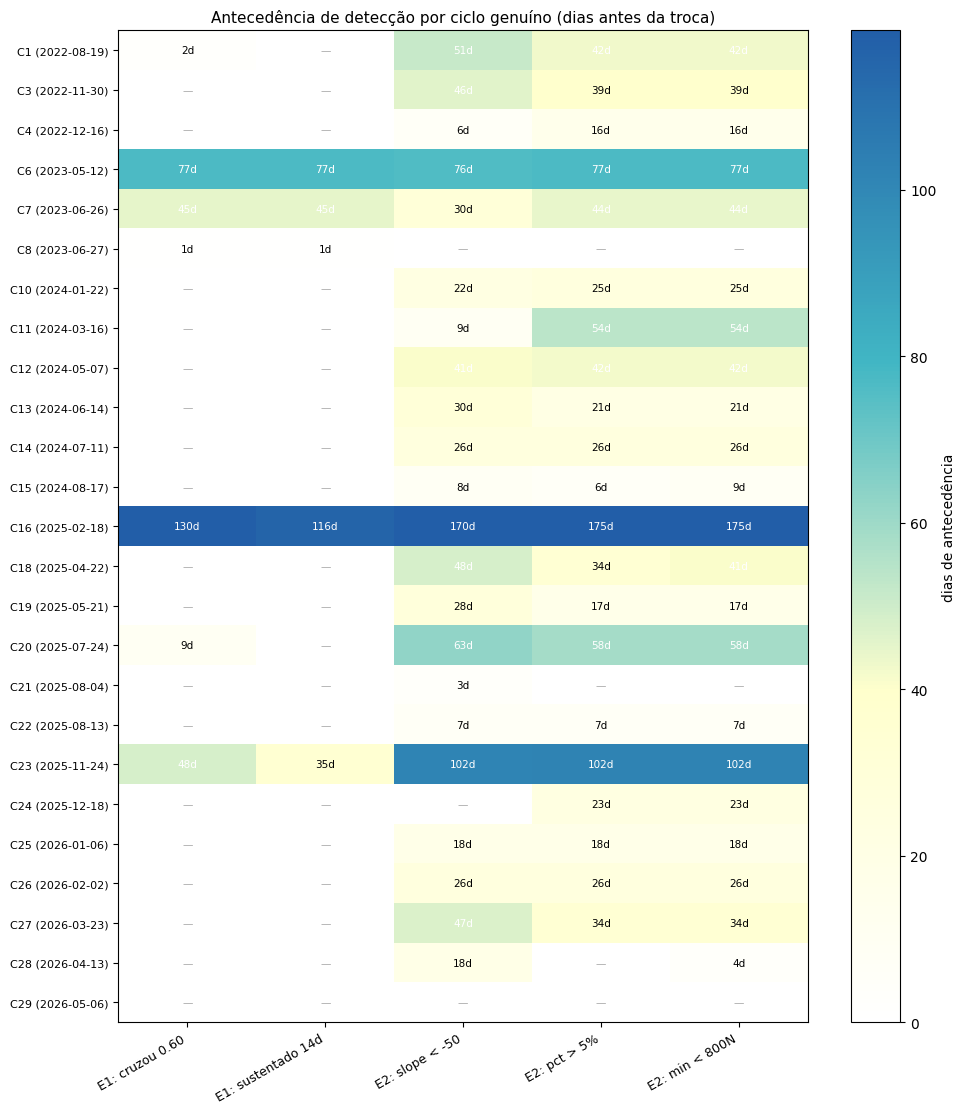

In [14]:
# Heatmap: ciclo × sinal — quantos dias de antecedência
heat_cols = ['e1_cruzou', 'e1_sustentado', 'e2_slope', 'e2_pct', 'e2_min']
heat_labels = ['E1: cruzou 0.60', 'E1: sustentado 14d',
               'E2: slope < -50', 'E2: pct > 5%', 'E2: min < 800N']

mat = genuinos[heat_cols].values.astype(float)
y_labels = [f"C{row['ciclo_id']} ({row['troca_fim']})" for _, row in genuinos.iterrows()]

fig, ax = plt.subplots(figsize=(10, max(6, len(genuinos) * 0.45)))

# Colorir: branco=sem detecção, gradiente=dias de antecedência
cmap = mcolors.LinearSegmentedColormap.from_list(
    'leads', ['white', '#ffffcc', '#41b6c4', '#225ea8'], N=256)
masked = np.ma.masked_invalid(mat)
im = ax.imshow(masked, aspect='auto', cmap=cmap,
               vmin=0, vmax=max(60, np.nanpercentile(mat, 95) if not np.all(np.isnan(mat)) else 60))

# Valores nas células
for r in range(mat.shape[0]):
    for c in range(mat.shape[1]):
        val = mat[r, c]
        if not np.isnan(val):
            ax.text(c, r, f'{val:.0f}d', ha='center', va='center',
                    fontsize=7.5, color='black' if val < 40 else 'white')
        else:
            ax.text(c, r, '—', ha='center', va='center', fontsize=7.5, color='#aaa')

ax.set_xticks(range(len(heat_cols)))
ax.set_xticklabels(heat_labels, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_title('Antecedência de detecção por ciclo genuíno (dias antes da troca)', fontsize=11)
plt.colorbar(im, ax=ax, label='dias de antecedência')
plt.tight_layout()
plt.savefig('03_heatmap_antecedencia.png', dpi=130, bbox_inches='tight')
plt.show()

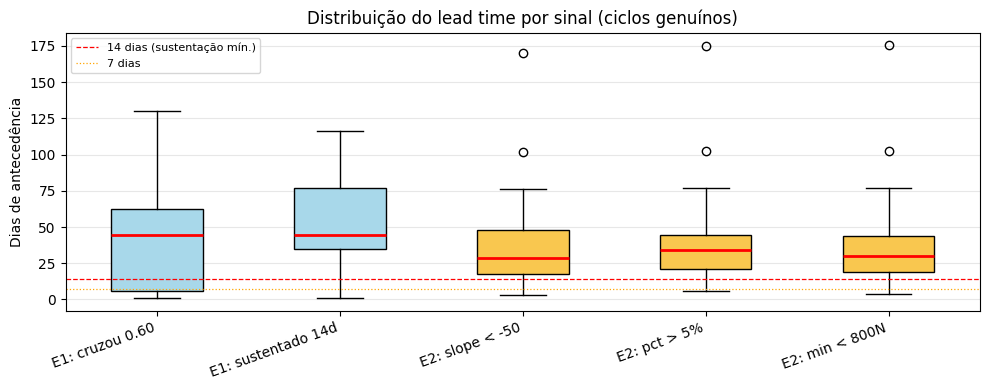

In [15]:
# Boxplot de lead time por sinal
fig, ax = plt.subplots(figsize=(10, 4))

data_box = [genuinos[col].dropna().values for col in heat_cols]
bp = ax.boxplot(data_box, labels=heat_labels, patch_artist=True,
                medianprops={'color': 'red', 'lw': 2})
colors = ['#a8d8ea', '#a8d8ea', '#f9c74f', '#f9c74f', '#f9c74f']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Dias de antecedência')
ax.set_title('Distribuição do lead time por sinal (ciclos genuínos)')
ax.axhline(14, color='red', ls='--', lw=0.9, label='14 dias (sustentação mín.)')
ax.axhline(7,  color='orange', ls=':', lw=0.9, label='7 dias')
plt.xticks(rotation=20, ha='right')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('03_boxplot_lead.png', dpi=120, bbox_inches='tight')
plt.show()

## Etapa F — Exportar `03_padroes.csv`

In [16]:
padroes.to_csv('03_padroes.csv', index=False)
print(f'Exportado: 03_padroes.csv  ({len(padroes)} linhas)')
print()

# Resumo final
print('=' * 60)
print('  RESUMO FINAL — VALIDAÇÃO DE THRESHOLDS')
print('=' * 60)
print(f'  Ciclos genuínos analisados : {n_gen}')
print(f'  Cobertura Eixo 1 (cruzou)  : {coberto_e1}/{n_gen}  '
      f'({coberto_e1/n_gen:.0%})')
print(f'  Cobertura Eixo 2 (qualquer): {coberto_e2}/{n_gen}  '
      f'({coberto_e2/n_gen:.0%})')
print(f'  Cobertura combinada        : {coberto_comb}/{n_gen}  '
      f'({coberto_comb/n_gen:.0%})')
if len(lc) > 0:
    print(f'  Lead time mediano (comb.)  : {lc.median():.1f} dias')
print('=' * 60)
print()
print('Thresholds validados contra histórico FB14:')
print(f'  score_roll7d ≥ {SCORE_CRITICO}      → G0/G1/G2 (Eixo 1)')
print(f'  slope_Media_7d < {SLOPE_THRESHOLD} N/dia → G_F1 (Eixo 2)')
print(f'  min_forca_3d   < {FORCA_LIMIAR} N   → G_F1/G_F2/G_F3 (Eixo 2)')
print(f'  pct_abaixo_800N_7d > {PCT_LIMIAR:.0%}  → G_F2/G_F3 (Eixo 2)')

Exportado: 03_padroes.csv  (29 linhas)

  RESUMO FINAL — VALIDAÇÃO DE THRESHOLDS
  Ciclos genuínos analisados : 25
  Cobertura Eixo 1 (cruzou)  : 7/25  (28%)
  Cobertura Eixo 2 (qualquer): 23/25  (92%)
  Cobertura combinada        : 24/25  (96%)
  Lead time mediano (comb.)  : 29.0 dias

Thresholds validados contra histórico FB14:
  score_roll7d ≥ 0.6      → G0/G1/G2 (Eixo 1)
  slope_Media_7d < -50.0 N/dia → G_F1 (Eixo 2)
  min_forca_3d   < 800.0 N   → G_F1/G_F2/G_F3 (Eixo 2)
  pct_abaixo_800N_7d > 5%  → G_F2/G_F3 (Eixo 2)
